# TSMixer for ETF Cross-Asset Lead-Lag

Cross-asset ETFs exhibit lead-lag relationships: TLT leads equity volatility
shifts, GLD leads inflation expectations, and sector ETFs co-move in
regime-dependent clusters. TSMixer's channel-mixing architecture is built for
exactly this structure - its alternating time-mixing and feature-mixing layers
can learn cross-asset temporal interactions that a flat-feature model cannot
express. The 60-day lookback window covers the multi-week regime transitions
where these lead-lag relationships are strongest.

The question this notebook asks is whether that inductive bias pays off:
does cross-asset feature mixing lift the cross-sectional IC above the Ridge
(Ch11) and GBM (Ch12) baselines on the same ETF cross-section? The results are
read back from the frozen results registry - no GPU retraining happens on a
cached checkout.

**Learning Objectives**:
- Read TSMixer walk-forward checkpoint results from the frozen registry
- Tune the checkpoint (epoch count) on validation via the shared grid, holdout sealed
- Place TSMixer against the linear and GBM baselines on the same cross-section
- Assess whether cross-asset feature mixing lifts IC above those baselines

**Book Reference**: Chapter 13, Section 13.8 (Case Study Results)

**Prerequisites**: [`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb),
[`09_dl_lstm`](09_dl_lstm.ipynb) (for baselines)

In [1]:
"""TSMixer - ETF deep learning with registered walk-forward checkpoints."""

import sqlite3
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml

import utils.style  # noqa: F401 - activates the ML4T Plotly template
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.darts_forecasting import (
    darts_training_identity,
    select_full_coverage_checkpoint,
)
from case_studies.utils.deep_learning import run_dl_cv
from case_studies.utils.latent_factors.case_study import _training_input_identity
from case_studies.utils.registry import (
    build_training_spec,
    load_prediction_metrics,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
MODEL = "tsmixer"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

dl_config = setup.get("modeling", {}).get("dl", {}) or {}
DEVICE = dl_config.get("device", "gpu")

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID} | Model: {MODEL}")
print(f"Device: {device_str} | Epochs: {N_EPOCHS} | Lookback: {LOOKBACK}")

Label from setup.yaml: fwd_ret_21d
Case study: etfs | Model: tsmixer
Device: cuda | Epochs: 100 | Lookback: 60


## 1. Load Data

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
input_data_spec = _training_input_identity(CASE_STUDY_ID, PRIMARY_LABEL)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows x {n_features} features")
print(f"Label: {label_col} | Entity: {entity_col} | Folds: {len(splits)}")
print(f"Input digest: {input_data_spec['input_digest']}")

dataset_pd = dataset.to_pandas()
n_entities = dataset_pd[entity_col].nunique()
print(f"Entities: {n_entities}")

Dataset: 394,233 rows x 71 features
Label: fwd_ret_21d | Entity: symbol | Folds: 8
Entities: 99


## 2. Prior Baselines

The linear (Ch11) and GBM (Ch12) leaders are read from the frozen registry for
the same label and validation split, rather than re-run here. They are the
reference the TSMixer result has to clear.

In [5]:
ridge_ic = float("nan")
gbm_ic = float("nan")
_baselines = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID])
for row in _baselines.iter_rows(named=True):
    if row["family"] == "linear" and row["ic_mean"] is not None:
        ridge_ic = float(row["ic_mean"])
    elif row["family"] == "gbm" and row["ic_mean"] is not None:
        gbm_ic = float(row["ic_mean"])

prior_baselines = {"Ridge (Ch11)": ridge_ic, "GBM (Ch12)": gbm_ic}
for name, ic in prior_baselines.items():
    print(f"  {name}: IC={ic:+.4f}" if np.isfinite(ic) else f"  {name}: IC=N/A")

  Ridge (Ch11): IC=+0.0420
  GBM (Ch12): IC=+0.0440


## 3. TSMixer Checkpoints

The results registry (`run_log/registry.db`) is the frozen source of truth for
this case study. The TSMixer config was trained walk-forward with
cross-sectional IC evaluated at checkpoints, and each checkpoint is stored as a
prediction set with its validation IC. Here we read those checkpoints back from
the registry rather than retraining: on a cached checkout no GPU work happens
and the frozen registry is never rewritten. Only a config with no registered
validation predictions (a fresh reader who deleted the registry) triggers a
`run_dl_cv` train.

In [6]:
dl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
dl_configs = [c for c in dl_configs if c["params"].get("architecture") == MODEL]

# Apply Papermill overrides. N_EPOCHS is part of the training spec hash, so it
# selects which registered run to read: the frozen registry was built at
# N_EPOCHS=100, and changing it here would miss the cache and trigger a fresh GPU
# train that rewrites the registry. The defaults below match the frozen run, so
# these are no-ops on a cached checkout.
for cfg in dl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 2048) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE
    if cfg["params"].get("lookback", 60) != LOOKBACK:
        cfg["params"]["lookback"] = LOOKBACK

print(f"Grid: {len(dl_configs)} config x {len(splits)} folds (checkpoints read from registry)")
for cfg in dl_configs:
    print(f"  {cfg['config_name']}: {cfg['params'].get('architecture', '?')}")

expected_fold_ids = sorted(int(split["fold"]) for split in splits)
expected_validation_days = sum(
    dataset_pd.loc[
        (dataset_pd[date_col] >= split["val_start"]) & (dataset_pd[date_col] <= split["val_end"]),
        date_col,
    ].nunique()
    for split in splits
)

Grid: 1 config x 8 folds (checkpoints read from registry)
  tsmixer: tsmixer


In [7]:
def _rebuild_from_registry(cfg: dict) -> dict | None:
    """Rebuild one config's checkpoint curve + peak IC from the frozen registry.

    Returns None if the config has no complete registered validation set (a fresh
    reader who deleted the registry), in which case it is queued for training.
    """
    identity_params = darts_training_identity(
        cfg,
        label_col,
        case_study=CASE_STUDY_ID,
        input_data_spec=input_data_spec,
        max_train_sequences=0,
    )
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=cfg.get("n_epochs"),
        extra_params=identity_params,
    )
    status = training_run_status(CASE_STUDY_ID, spec)
    t_hash = training_hash_from_spec(spec)
    psets = load_prediction_sets(CASE_STUDY_ID, training_hash=t_hash, split=PREDICTION_SPLIT)
    if not status.complete or psets.is_empty():
        return None

    interval = int(cfg.get("checkpoint_interval", cfg.get("n_epochs", N_EPOCHS)))
    total_epochs = int(cfg.get("n_epochs", N_EPOCHS))
    expected_epochs = list(range(interval, total_epochs + 1, interval))
    if not expected_epochs or expected_epochs[-1] != total_epochs:
        expected_epochs.append(total_epochs)
    actual_epochs = sorted(int(value) for value in psets["checkpoint_value"].to_list())
    if actual_epochs != expected_epochs:
        return None

    curve = []
    with sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as connection:
        for row in psets.iter_rows(named=True):
            prediction_hash = row["prediction_hash"]
            prediction_path = (
                CASE_DIR / "run_log" / "predictions" / prediction_hash / "predictions.parquet"
            )
            fold_ids = [
                int(item[0])
                for item in connection.execute(
                    "SELECT fold_id FROM fold_metrics WHERE prediction_hash = ? ORDER BY fold_id",
                    (prediction_hash,),
                ).fetchall()
            ]
            m = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash)
            if m.is_empty() or not prediction_path.exists() or fold_ids != expected_fold_ids:
                return None
            nd = m["ic_n_days"][0]
            daily_ic = m["ic_mean_daily"][0]
            if nd is None or daily_ic is None:
                return None
            curve.append(
                {
                    "config": cfg["config_name"],
                    "epoch": int(row["checkpoint_value"]),
                    "ic_mean": float(daily_ic),
                    "ic_n_days": float(nd),
                    "prediction_hash": prediction_hash,
                }
            )
    curve.sort(key=lambda c: c["epoch"])
    peak, full_days, partial_epochs = select_full_coverage_checkpoint(curve)
    if full_days != expected_validation_days:
        return None
    return {
        "config_name": cfg["config_name"],
        "best_epoch": peak["epoch"],
        "best_ic": peak["ic_mean"],
        "ic_n_days": peak["ic_n_days"],
        "best_prediction_hash": peak["prediction_hash"],
        "curve": curve,
        "full_days": full_days,
        "partial_epochs": partial_epochs,
        "cached": True,
    }


grid_results = []
to_train = []
for cfg in dl_configs:
    rebuilt = _rebuild_from_registry(cfg)
    if rebuilt is not None:
        grid_results.append(rebuilt)
        print(
            f"  {rebuilt['config_name']:10s}  epoch={rebuilt['best_epoch']:4d}  "
            f"IC={rebuilt['best_ic']:+.4f}  (cached)"
        )
    else:
        to_train.append(cfg)

# Uncached configs (none on the frozen registry) train via run_dl_cv, which
# writes the registry. On a cached checkout `to_train` is empty, so no GPU work
# runs and the frozen registry stays byte-identical.
if to_train:
    print(f"\nTraining {len(to_train)} uncached config(s)...")
    run_dl_cv(
        dataset_pd,
        splits,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        configs=to_train,
        n_features=n_features,
        device=device_str,
        save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
        register=True,
        force_retrain=FORCE_RETRAIN,
        prediction_split=PREDICTION_SPLIT,
        case_study=CASE_STUDY_ID,
        notebook=f"dl_{MODEL}",
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
        input_data_spec=input_data_spec,
    )
    for cfg in to_train:
        rebuilt = _rebuild_from_registry(cfg)
        if rebuilt is None:
            raise RuntimeError(
                f"Training completed but registered checkpoints are incomplete for "
                f"{cfg['config_name']}"
            )
        rebuilt["cached"] = False
        grid_results.append(rebuilt)

  tsmixer     epoch=  15  IC=+0.0290  (cached)


## 4. Winner and Baselines

The reported IC is the config's **peak-checkpoint** validation value: the epoch
count is tuned on the validation folds by scanning the checkpoint grid and
keeping the checkpoint with the highest mean cross-sectional IC (the epoch-count
analogue of early stopping). The holdout is never touched here.

A full-coverage guard mirrors `06_linear`, `07_gbm`, and `13_model_analysis`: a
checkpoint that collapses to near-constant predictions on some folds produces no
cross-sectional IC on those validation dates, so its IC is measured on fewer
days (`ic_n_days` below the maximum) and is not comparable. Such checkpoints are
excluded from the winner. On the frozen registry every TSMixer checkpoint is
full-coverage (2016 days), so the guard is inert here.

In [8]:
grid_results.sort(
    key=lambda r: r["best_ic"] if np.isfinite(r["best_ic"]) else -np.inf, reverse=True
)

_finite_days = [r["ic_n_days"] for r in grid_results if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in grid_results
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in grid_results if r not in full_cov]
else:
    _full_days = None
    full_cov = grid_results
    partial_cov = []

best = full_cov[0] if full_cov else None
best_name = best["config_name"] if best else None
best_epoch = best["best_epoch"] if best else 0
best_ic = best["best_ic"] if best else float("nan")

print(f"{'Config':10s} {'Best Epoch':>10s} {'Peak IC':>10s} {'N Days':>8s}")
print("-" * 42)
for r in full_cov:
    marker = " *" if r is best else ""
    _nd = r.get("ic_n_days", np.nan)
    _nd_str = f"{int(_nd):>8d}" if np.isfinite(_nd) else f"{'n/a':>8s}"
    print(f"{r['config_name']:10s} {r['best_epoch']:10d} {r['best_ic']:+10.4f} {_nd_str}{marker}")

if partial_cov:
    print("\nPartial coverage (degenerate on some folds - excluded from ranking):")
    for r in partial_cov:
        _nd = r.get("ic_n_days", np.nan)
        _nd_str = f"{int(_nd)}" if np.isfinite(_nd) else "n/a"
        print(f"  {r['config_name']:10s}  IC={r['best_ic']:+.4f}  n_days={_nd_str}")

if best:
    print(f"\nBest (full coverage): {best_name} @ epoch {best_epoch} (IC={best_ic:+.4f})")
print(f"Baselines - Ridge (Ch11): {ridge_ic:+.4f} | GBM (Ch12): {gbm_ic:+.4f}")

Config     Best Epoch    Peak IC   N Days
------------------------------------------
tsmixer            15    +0.0290     2016 *

Best (full coverage): tsmixer @ epoch 15 (IC=+0.0290)
Baselines - Ridge (Ch11): +0.0420 | GBM (Ch12): +0.0440


### TSMixer against the baselines

The bar chart places the peak TSMixer IC next to the Ridge (Ch11) and GBM
(Ch12) leaders on the same label and validation split. TSMixer sits below both:
on this cross-section the channel-mixing architecture does not add
cross-sectional IC over a heavily regularized linear model or a shallow-tree
GBM.

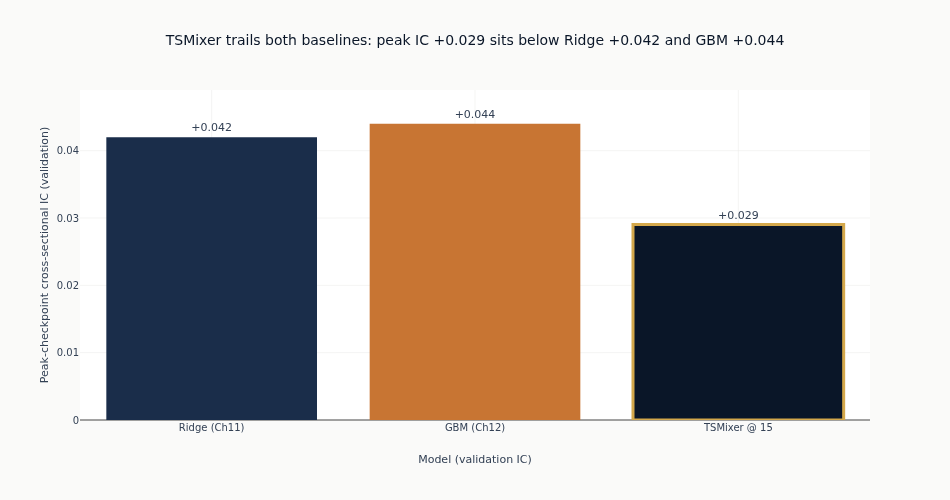

In [9]:
# IC comparison - TSMixer vs the flat-feature baselines, TSMixer outlined.
_cmp_names = ["Ridge (Ch11)", "GBM (Ch12)", f"TSMixer @ {best_epoch}"]
_cmp_ics = [ridge_ic, gbm_ic, best_ic]
_colors = [COLORS["slate"], COLORS["copper"], COLORS["blue"]]
_line_w = [0, 0, 3]
fig_cmp = go.Figure(
    go.Bar(
        x=_cmp_names,
        y=_cmp_ics,
        marker=dict(color=_colors, line=dict(color=COLORS["amber"], width=_line_w)),
        text=[f"{v:+.3f}" for v in _cmp_ics],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
fig_cmp.update_layout(
    title=(
        f"TSMixer trails both baselines: peak IC {best_ic:+.3f} sits below "
        f"Ridge {ridge_ic:+.3f} and GBM {gbm_ic:+.3f}"
    ),
    height=500,
    width=950,
    margin=dict(t=90),
)
fig_cmp.update_xaxes(title_text="Model (validation IC)")
fig_cmp.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_cmp.show()

## 5. Learning Curve

Validation IC at each registered checkpoint traces how TSMixer trains. The peak
is the earliest checkpoint: IC is highest after 15 epochs and then decays toward
zero by epoch 90. Rather than converging onto a stable cross-asset signal, the
model degrades as training continues - the pattern of a weak signal that the
network overfits away, not one it consolidates.

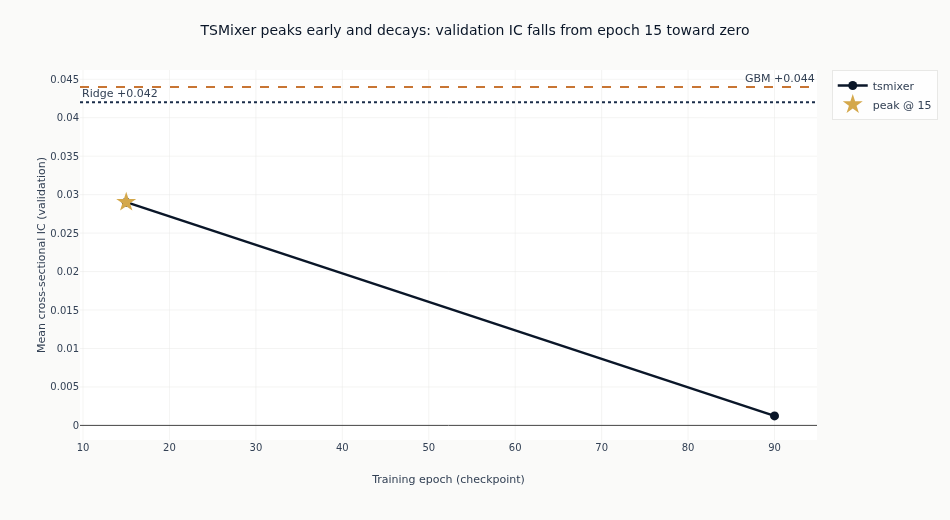

Config       epoch        IC   N days
tsmixer         15   +0.0290     2016
tsmixer         90   +0.0012     2016


In [10]:
all_curves = pl.DataFrame([c for r in grid_results for c in r["curve"]])
if all_curves.height > 0:
    cfg_data = all_curves.filter(pl.col("config") == best_name).sort("epoch")
    fig_lc = go.Figure(
        go.Scatter(
            x=cfg_data["epoch"].to_list(),
            y=cfg_data["ic_mean"].to_list(),
            mode="lines+markers",
            name=best_name,
            line=dict(color=COLORS["blue"], width=2.5),
            marker=dict(size=9, color=COLORS["blue"]),
        )
    )
    # Highlight the selected peak checkpoint.
    fig_lc.add_trace(
        go.Scatter(
            x=[best_epoch],
            y=[best_ic],
            mode="markers",
            name=f"peak @ {best_epoch}",
            marker=dict(size=15, color=COLORS["amber"], symbol="star"),
        )
    )
    fig_lc.add_hline(
        y=ridge_ic,
        line=dict(color=COLORS["slate"], width=2, dash="dot"),
        annotation_text=f"Ridge {ridge_ic:+.3f}",
        annotation_position="top left",
    )
    fig_lc.add_hline(
        y=gbm_ic,
        line=dict(color=COLORS["copper"], width=2, dash="dash"),
        annotation_text=f"GBM {gbm_ic:+.3f}",
        annotation_position="top right",
    )
    fig_lc.update_layout(
        title="TSMixer peaks early and decays: validation IC falls from epoch 15 toward zero",
        height=520,
        width=950,
        legend=dict(title="", font=dict(size=11)),
        margin=dict(t=70),
    )
    fig_lc.update_xaxes(title_text="Training epoch (checkpoint)")
    fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    fig_lc.show()

    print(f"{'Config':10s}{'epoch':>8s}{'IC':>10s}{'N days':>9s}")
    for c in cfg_data.iter_rows(named=True):
        print(f"{c['config']:10s}{c['epoch']:8d}{c['ic_mean']:+10.4f}{int(c['ic_n_days']):9d}")

## 6. Winner Fold Metrics

The winner's validation IC is the mean of its per-fold cross-sectional IC.
Reading the fold breakdown from the frozen registry shows how uneven that
average is: the headline IC rests on two strong folds and turns negative on
folds 4 and 5, a sign the cross-asset edge is not stable across the walk-forward.

In [11]:
if best and best.get("best_prediction_hash"):
    import sqlite3

    con = sqlite3.connect(CASE_DIR / "run_log" / "registry.db")
    try:
        fold_rows = con.execute(
            "SELECT fold_id, ic, n_entities FROM fold_metrics "
            "WHERE prediction_hash = ? ORDER BY fold_id",
            (best["best_prediction_hash"],),
        ).fetchall()
    finally:
        con.close()
    print(f"Per-fold validation IC ({best_name} @ epoch {best_epoch}):")
    for fold_id, ic, n_ent in fold_rows:
        print(f"  Fold {fold_id}: IC={ic:+.4f}  n_entities={int(n_ent)}")
    _fold_mean = float(np.mean([r[1] for r in fold_rows])) if fold_rows else float("nan")
    print(f"\n  Mean fold IC: {_fold_mean:+.4f}  (registered peak IC: {best_ic:+.4f})")

Per-fold validation IC (tsmixer @ epoch 15):
  Fold 0: IC=+0.0142  n_entities=96
  Fold 1: IC=+0.0573  n_entities=97
  Fold 2: IC=+0.1161  n_entities=95
  Fold 3: IC=+0.0449  n_entities=96
  Fold 4: IC=-0.0421  n_entities=96
  Fold 5: IC=-0.0724  n_entities=90
  Fold 6: IC=+0.1109  n_entities=88
  Fold 7: IC=+0.0033  n_entities=86

  Mean fold IC: +0.0290  (registered peak IC: +0.0290)


## 7. Registered Predictions

Every checkpoint's validation predictions are already persisted in
`run_log/registry.db`, and the backtest reads the winner's prediction set
directly. No retraining or re-saving happens on a cached checkout.

In [12]:
if best and best.get("best_prediction_hash"):
    _winner_set = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=None,
        split=PREDICTION_SPLIT,
    ).filter(pl.col("prediction_hash") == best["best_prediction_hash"])
    print(f"Winner prediction_hash: {best['best_prediction_hash']}")
    print(f"Registered checkpoints for {best_name}: {all_curves.height}")
    print(f"Winner set rows in registry: {_winner_set.height}")

Winner prediction_hash: dd35f0070431
Registered checkpoints for tsmixer: 2
Winner set rows in registry: 1


## 8. Key Takeaways

- **TSMixer underperforms both baselines here.** The peak TSMixer checkpoint
  reaches validation IC $\approx +0.029$ (at 15 epochs), below the GBM leader
  (`leaves_7_mae`, $\approx +0.044$ from [`07_gbm`](07_gbm.ipynb)) and the
  full-coverage linear leader (Ridge at $\alpha = 10^6$, $\approx +0.042$ from
  [`06_linear`](06_linear.ipynb)). The channel-mixing inductive bias does not
  lift IC above a shallow-tree GBM or a heavily regularized linear model on this
  cross-section.
- **The signal peaks early and decays.** IC is highest at the first checkpoint
  (15 epochs) and falls toward zero by epoch 90. That is the signature of a weak
  signal the network overfits away with more training, not of stable cross-asset
  structure it consolidates - so the "fast convergence" is not evidence of
  learnable lead-lag structure here.
- **The edge is fold-fragile.** The winner's IC is carried by folds 2 and 6 and
  goes negative on folds 4 and 5, so the $+0.029$ is not a stable cross-sectional
  signal. The epoch count is tuned on the validation folds via the checkpoint
  grid, the analogue of early stopping; the holdout is untouched.

On this ETF cross-section the predictable structure is largely captured by the
flat-feature baselines, and neither the TabM ensemble (Ch12), the LSTM, nor
TSMixer's cross-asset mixing clears them on validation IC. That motivates the
latent-factor view next: extracting a small set of factors may organize the
cross-section more parsimoniously than a full sequence model.

**Next**: [`11_latent_factors`](11_latent_factors.ipynb) tests whether
PCA-based factor extraction captures the same cross-asset structure more
parsimoniously.
**Book**: Chapter 13.8 reports the case-study results across architectures.